In [2]:
import pandas as pd
df_1 = pd.read_csv('api_data_aadhar_biometric_500000_1000000.csv')
df_2 = pd.read_csv('api_data_aadhar_biometric_1500000_1861108.csv')
df_3 = pd.read_csv('api_data_aadhar_biometric_0_500000.csv')
df_4 = pd.read_csv('api_data_aadhar_biometric_1000000_1500000.csv')
combined_df = pd.concat([df_1, df_2, df_3, df_4], ignore_index=True)
print("Shape of combined_df:", combined_df.shape)

Shape of combined_df: (1861108, 6)


In [3]:
combined_df['total_biometric'] = combined_df['bio_age_5_17'] + combined_df['bio_age_17_']
display(combined_df.head())

,date,state,district,pincode,bio_age_5_17,bio_age_17_,total_biometric
0,19-09-2025,Goa,North Goa,403502,0,4,4
1,19-09-2025,Goa,North Goa,403508,1,4,5
2,19-09-2025,Goa,North Goa,403513,2,0,2
3,19-09-2025,Goa,North Goa,403527,2,2,4
4,19-09-2025,Goa,South Goa,403601,7,3,10


In [4]:
combined_df =combined_df[combined_df.pincode!=100000]

In [5]:
# state_wise_total_biometric
combined_df['state'] = combined_df['state'].str.strip()
combined_df['state'] = combined_df['state'].str.title()

state_name_mapping = {
    'Andaman & Nicobar Islands': 'Andaman and Nicobar Islands',    'Andaman And Nicobar Islands': 'Andaman and Nicobar Islands',
    'Dadra & Nagar Haveli': 'Dadra and Nagar Haveli',     'Dadra And Nagar Haveli': 'Dadra and Nagar Haveli',     'Daman & Diu': 'Daman and Diu',
    'Daman And Diu': 'Daman and Diu',  'Orissa': 'Odisha',    'Uttaranchal' : 'Uttarakhand',    'Pondicherry': 'Puducherry',    'Jammu & Kashmir': 'Jammu and Kashmir',
    'Jammu And Kashmir': 'Jammu and Kashmir',    'West  Bengal': 'West Bengal',    'West Bangal': 'West Bengal',    'West Bengal': 'West Bengal',
    'Westbengal': 'West Bengal',    'Tamilnadu' : 'Tamil Nadu',    'Dadra And Nagar Haveli': 'Dadra and Nagar Haveli and Daman and Diu',
    'Dadra & Nagar Haveli': 'Dadra and Nagar Haveli and Daman and Diu',    'Dadra And Nagar Haveli And Daman And Diu': 'Dadra and Nagar Haveli and Daman and Diu',
    'The Dadra And Nagar Haveli': 'Dadra and Nagar Haveli and Daman and Diu',    'Daman And Diu': 'Dadra and Nagar Haveli and Daman and Diu',
    'Daman & Diu': 'Dadra and Nagar Haveli and Daman and Diu',    'The Dadra And Nagar Haveli And Daman And Diu': 'Dadra and Nagar Haveli and Daman and Diu',
    'Dadra and Nagar Haveli And Daman And Diu': 'Dadra and Nagar Haveli and Daman and Diu',    'Nct Of Delhi': 'Delhi',
    'Chhatisgarh': 'Chhattisgarh'
}

combined_df['state'] = combined_df['state'].replace(state_name_mapping)

print(combined_df.head())

         date state   district  pincode  bio_age_5_17  bio_age_17_  \
0  19-09-2025   Goa  North Goa   403502             0            4   
1  19-09-2025   Goa  North Goa   403508             1            4   
2  19-09-2025   Goa  North Goa   403513             2            0   
3  19-09-2025   Goa  North Goa   403527             2            2   
4  19-09-2025   Goa  South Goa   403601             7            3   

   total_biometric  
0                4  
1                5  
2                2  
3                4  
4               10  


In [6]:
print("Total States : ",len(combined_df['state'].value_counts()))
print(combined_df['state'].value_counts())

Total States :  36
state
Tamil Nadu                                  184569
Andhra Pradesh                              172065
Uttar Pradesh                               155242
Maharashtra                                 151104
Karnataka                                   141227
West Bengal                                 130895
Odisha                                       99674
Kerala                                       98511
Gujarat                                      89531
Bihar                                        83398
Telangana                                    82579
Rajasthan                                    79724
Madhya Pradesh                               70080
Punjab                                       48108
Assam                                        47643
Jharkhand                                    36625
Chhattisgarh                                 31997
Himachal Pradesh                             30385
Haryana                                      26429
Uttara

In [7]:
# Step 1: Identify variations and misspellings in district names
district_name_mapping = {
    "Ahmadnagar": "Ahilyanagar",
"Aurangabad": "Chhatrapati Sambhajinagar",

    'Kushinagar *': 'Kushinagar','Siddharth Nagar': 'Siddharthnagar', 'Bagpat': 'Baghpat',   'Bulandshahar': 'Bulandshahr',  'Sant Ravidas Nagar': 'Bhadohi',    'Bara Banki': 'Barabanki','Raebareli': 'Rae Bareli', 'Sant Ravidas Nagar Bhadohi': 'Sant Ravidas Nagar',
    'Ambedkar Nagar': 'Ambedkar Nagar',  'Prayagraj': 'Allahabad',  'Faizabad': 'Ayodhya', 'Jyotiba Phule Nagar': 'Amroha', 'Kushi Nagar': 'Kushinagar',  'Maharajganj': 'Mahrajganj',    'Shravasti': 'Shrawasti',    'Kanpur Nagar': 'Kanpur Urban',    'Kanpur Nagr': 'Kanpur Urban',
    'Aurangabad(bh)': 'Aurangabad',    'Aurangabad(BH)': 'Aurangabad',    'Bangalore Urban': 'Bengaluru Urban',    'Mumbai City': 'Mumbai Suburban',  'Kanchipuram': 'Kancheepuram',
    'Kanyakumari': 'Kanniyakumari',    'Namakkal   *': 'Namakkal', 'Thiruvallur': 'Tiruvallur',    'Tirupathur': 'Tirupattur',    'Thiruvarur': 'Tiruvarur',    'Tuticorin': 'Thoothukkudi',    'Villupuram': 'Viluppuram',
    'Ahilyanagar': 'Ahmadnagar',    'Ahmed Nagar': 'Ahmadnagar',    'Ahmednagar': 'Ahmadnagar',    'Bid': 'Beed',
    'Buldana': 'Buldhana',    'Chatrapati Sambhaji Nagar': 'Chhatrapati Sambhajinagar',    'Gondiya': 'Gondia',    'Gondiya *': 'Gondia',    'Hingoli *': 'Hingoli',    'Mumbai( Sub Urban )': 'Mumbai Suburban',
    'Nandurbar *': 'Nandurbar',    'Osmanabad': 'Dharashiv', 'Raigarh': 'Raigad',    'Raigarh(Mh)': 'Raigad',    'Washim *': 'Washim', '24 Paraganas North': 'North 24 Parganas',
    'North Twenty Four Parganas': 'North 24 Parganas',    '24 Paraganas South': 'South 24 Parganas',    'South 24 Pargana': 'South 24 Parganas', 'South Twenty Four Parganas': 'South 24 Parganas',    'Cooch Behar': 'Coochbehar',
    'Koch Bihar': 'Coochbehar',    'Darjiling': 'Darjeeling',    'Dinajpur Dakshin': 'Dakshin Dinajpur',    'South Dinajpur': 'Dakshin Dinajpur',    'Dinajpur Uttar': 'Uttar Dinajpur',    'North Dinajpur': 'Uttar Dinajpur',    'East Midnapore': 'Purba Medinipur',    'East Midnapur': 'Purba Medinipur',
    'West Medinipur': 'Paschim Medinipur',    'West Midnapore': 'Paschim Medinipur',    'Medinipur West': 'Paschim Medinipur',    'Medinipur': 'Paschim Medinipur',    'Haora': 'Howrah',    'Hawrah': 'Howrah',    'Hooghiy': 'Hooghly',    'Hugli': 'Hooghly',    'Maldah': 'Malda',    'Puruliya': 'Purulia',
    'Ananthapur': 'Anantapur',    'Ananthapuramu': 'Anantapur',    'Cuddapah': 'Y.S.R. Kadapa', 'K.V. Rangareddy': 'Ranga Reddy',    'K.V.Rangareddy': 'Ranga Reddy',    'Rangareddi': 'Ranga Reddy',    'Karim Nagar': 'Karimnagar',
    'Mahabub Nagar': 'Mahabubnagar',    'Mahbubnagar': 'Mahabubnagar',    'Spsr Nellore': 'Nellore',    'Sri Potti Sriramulu Nellore': 'Nellore',    'Visakhapatanam': 'Visakhapatnam',    'Y. S. R': 'Y.S.R. Kadapa',
    '*Khordha **': 'Khordha' , 'N. T. R': 'N.T.R.', '*Anugul **': 'Angul',    'Anugal': 'Angul'
}

district_name_mapping.update({
    "Balrampur–Ramanujganj": "Chhattisgarh",
"Mahrajganj": "Maharajganj",
"Allahabad": "Prayagraj",
    "Manendragarhchirmiribharatpur": "Manendragarh–Chirmiri–Bharatpur","Mahrajganj": "Maharajganj", "Maharajganj" : "Maharajganj",
    "Allahabad" : "Prayagraj", "Kanpur Nagar" : "Kanpur Urban", "Lakhimpur Kheri" : "Kheri",
    "Balrampur" : "Balrampur",
    "Auraiya *" : "Auraiya",
"Chandauli *" : "Chandauli",
"Gautam Buddha Nagar *" : "Gautam Buddha Nagar",
"Mahoba *" : "Mahoba",
"Balrampur–Ramanujganj" : "Balrampur",
"Allahabad" : "Prayagraj",
"Mahrajganj" : "Maharajganj",
"Kheri" : "Lakhimpur Kheri",
"Shrawasti" : "Shravasti",
"Kanpur Urban" : "Kanpur Nagar",
    "Tiswadi": "North Goa",
    'Kushinagar *': 'Kushinagar',  'Siddharth Nagar': 'Siddharthnagar',  'Bagpat': 'Baghpat', 'Bulandshahar': 'Bulandshahr', 'Sant Ravidas Nagar': 'Bhadohi',    'Bara Banki': 'Barabanki', 'Raebareli': 'Rae Bareli',  'Sant Ravidas Nagar Bhadohi': 'Sant Ravidas Nagar',    'Ambedkar Nagar': 'Ambedkar Nagar',
    'Prayagraj': 'Allahabad', 'Faizabad': 'Ayodhya', 'Jyotiba Phule Nagar': 'Amroha',    'Kushi Nagar': 'Kushinagar',  'Maharajganj': 'Mahrajganj',    'Shravasti': 'Shrawasti',    'Kanpur Nagar': 'Kanpur Urban',    'Kanpur Nagr': 'Kanpur Urban',    'Aurangabad(bh)': 'Aurangabad',    'Aurangabad(BH)': 'Aurangabad',    'Bangalore Urban': 'Bengaluru Urban',
    'Mumbai City': 'Mumbai Suburban',       'Kanchipuram': 'Kancheepuram',    'Kanyakumari': 'Kanniyakumari',    'Namakkal   *': 'Namakkal', 'Thiruvallur': 'Tiruvallur',    'Tirupathur': 'Tirupattur',    'Thiruvarur': 'Tiruvarur','Tuticorin': 'Thoothukkudi',    'Villupuram': 'Viluppuram',
   'Ahmadnagar': 'Ahilyanagar',    'Ahmed Nagar': 'Ahilyanagar',    'Ahmednagar': 'Ahilyanagar',       'Bid': 'Beed',        'Buldana': 'Buldhana',     'Aurangabad': 'Chhatrapati Sambhajinagar',    'Chatrapati Sambhaji Nagar': 'Chhatrapati Sambhajinagar',    'Gondiya': 'Gondia',    'Gondiya *': 'Gondia',   'Hingoli *': 'Hingoli',
  'Mumbai( Sub Urban )': 'Mumbai Suburban',   'Nandurbar *': 'Nandurbar',  'Osmanabad': 'Dharashiv',    'Raigarh(Mh)': 'Raigad',
     'Washim *': 'Washim',      "24 Paraganas North": "North 24 Parganas",    "North Twenty Four Parganas": "North 24 Parganas",    "24 Paraganas South": "South 24 Parganas",    "South 24 Pargana": "South 24 Parganas",    "South Twenty Four Parganas": "South 24 Parganas",
       "Cooch Behar": "Coochbehar",    "Koch Bihar": "Coochbehar",       "Darjiling": "Darjeeling",      "Dinajpur Dakshin": "Dakshin Dinajpur",    "South Dinajpur": "Dakshin Dinajpur",    "Dinajpur Uttar": "Uttar Dinajpur",    "North Dinajpur": "Uttar Dinajpur",
        "East Midnapore": "Purba Medinipur",    "East Midnapur": "Purba Medinipur",    "West Medinipur": "Paschim Medinipur",    "West Midnapore": "Paschim Medinipur",    "Medinipur West": "Paschim Medinipur",    "Medinipur": "Paschim Medinipur",   "Haora": "Howrah",    "Hawrah": "Howrah",    "Hooghiy": "Hooghly",    "Hugli": "Hooghly",
    "Maldah": "Malda",    "Puruliya": "Purulia",    "Barddhaman": "Purba Bardhaman",    "Bardhaman": "Purba Bardhaman",    "Burdwan": "Purba Bardhaman",     'Ananthapur': 'Anantapur',    'Ananthapuramu': 'Anantapur',    'Cuddapah': 'Y.S.R. Kadapa', 'K.V. Rangareddy': 'Ranga Reddy',    'K.V.Rangareddy': 'Ranga Reddy',    'Rangareddi': 'Ranga Reddy',    'Karim Nagar': 'Karimnagar',    'Khammam': 'Khammam',    'Mahabub Nagar': 'Mahabubnagar',    'Mahbubnagar': 'Mahabubnagar',    'Spsr Nellore': 'Nellore',
    'Sri Potti Sriramulu Nellore': 'Nellore',    'Visakhapatanam': 'Visakhapatnam',    'Y. S. R': 'Y.S.R. Kadapa',    'N. T. R': 'N.T.R.',       'North Delhi': 'North Delhi',    'South Delhi': 'South Delhi',    'East Delhi': 'East Delhi',    'West Delhi': 'West Delhi',
    'North East Delhi': 'North East',    'North West Delhi': 'North West',    'South West Delhi': 'South West Delhi',    'Central Delhi': 'Central Delhi',    'Shahdara': 'Shahdara',    'North East   *': 'North East',    'Najafgarh': 'South West Delhi'
})

district_name_mapping.update({
    "Bally Jagachha": "Howrah","Ahmadnagar": "Ahilyanagar",
"Aurangabad": "Chhatrapati Sambhajinagar",
    "Domjur": "Howrah","South Dumdum(M)": "North 24 Parganas","Coochbehar": "Cooch Behar",
    "Anugul  *" : "Angul", "Khordha  *" : "Khordha","Kendujhar": "Keonjhar",
    "Jagitial": "Jagtial","Jangoan": "Jangaon","Rangareddy": "Ranga Reddy","Medchal Malkajgiri": "Medchal–Malkajgiri","Medchal-Malkajgiri": "Medchal–Malkajgiri","Medchal?Malkajgiri": "Medchal–Malkajgiri","Medchal−Malkajgiri": "Medchal–Malkajgiri",
    "Warangal (Urban)": "Warangal","Warangal Urban": "Warangal",    "Warangal Rural": "Warangal","Yadadri.": "Yadadri Bhuvanagiri",'Anugal': 'Angul','Anugul':	'Angul','Baleshwar': 'Balasore','Baleswar': 'Balasore','Baudh':	'Boudh','Debagarh':	'Deogarh','Jagatsinghapur':	'Jagatsinghpur','Jajapur':	'Jajpur','Kendrapara *':	'Kendrapara','Khorda':	'Khordha','Nabarangapur':	'Nabarangpur','Sonapur':	'Subarnapur','Sundergarh':	'Sundargarh',
    'Kasargod'	:'Kasaragod',"Ramanagar": "Ramanagara",    "Tumkur": "Tumakuru",        "Bijapur": "Bijapur",    "Bangalore": "Bengaluru Urban",    "Bengaluru": "Bengaluru Urban",    "Bengaluru South": "Bengaluru Urban",    "Bangalore Rural": "Bengaluru Rural", "Bellary": "Ballari","Belgaum": "Belagavi",    "Gulbarga": "Kalaburagi",    "Shimoga": "Shivamogga", "Mysore": "Mysuru", "Tumkur": "Tumakuru",    "Ramanagar": "Ramanagara",    "Bijapur(KAR)": "Vijayapura",    "Bijapur(Kar)": "Vijayapura",      "Chickmagalur": "Chikkamagaluru",    "Chikmagalur": "Chikkamagaluru",    "Chikballapur": "Chikkaballapur",    "Davanagere": "Davangere",    "Hasan": "Hassan",
    "Chamrajanagar": "Chamarajanagar",    "Chamrajnagar": "Chamarajanagar",      "Bagalkot *": "Bagalkot",    "Chamarajanagar *": "Chamarajanagar",    "Gadag *": "Gadag",    "Haveri *": "Haveri",    "Udupi *": "Udupi",    'Baroda': 'Vadodara',    'Panchmahals': 'Panchmahal',    'Sabarkantha': 'Sabarkantha',    'Kutch': 'Kachchh',    'Kachchh': 'Kachchh',    "Ahmadabad": "Ahmedabad",    "Arvalli": "Aravalli",    "Banas Kantha": "Banaskantha",    "Dohad": "Dahod",
    "Panch Mahals": "Panchmahal",    "Sabar Kantha": "Sabarkantha",    "Surendra Nagar": "Surendranagar",    "Chhotaudepur": "Chhota Udaipur",    "The Dangs": "Dang",       'Dungarpur *': 'Dungarpur',    'Churu *': 'Churu',    'Sawai Madhopur *': 'Sawai Madhopur',    'Jodhpur *': 'Jodhpur',    'Jaipur *': 'Jaipur',    'Jhunjhunun': 'Jhunjhunu',   'Chittaurgarh': 'Chittorgarh', "Dhaulpur": "Dholpur",    "Jalor": "Jalore",    "Didwana-Kuchaman": "Didwana–Kuchaman",
    'Hoshangabad': 'Narmadapuram',    'Sehore *': 'Sehore',    'Shahdol *': 'Shahdol',    'Sidhi *': 'Sidhi',    'Ashoknagar': 'Ashok Nagar',    'Harda *': 'Harda',    'East Nimar': 'Khandwa',    'West Nimar': 'Khargone',    'Narsimhapur': 'Narsinghpur',
    'Kanker': 'Uttar Bastar Kanker',    'Bastar': 'Bastar',    'Dantewada': 'Dakshin Bastar Dantewada',    "Baloda Bazar": "Baloda Bazar–Bhatapara",    "Balrampur": "Balrampur–Ramanujganj",    "Gaurella Pendra Marwahi": "Gaurela–Pendra–Marwahi",    "Janjgir - Champa": "Janjgir–Champa",    "Janjgir Champa": "Janjgir–Champa",
    "Janjgir-Champa": "Janjgir–Champa",    "Kabeerdham": "Kabirdham",    "Kawardha": "Kabirdham",    "Raigad": "Raigarh", "Raigarh": "Raigad",  "Mohalla-Manpur-Ambagarh Chowki": "Mohla–Manpur–Ambagarh Chowki",    "Mohla-Manpur-Ambagarh Chouki": "Mohla–Manpur–Ambagarh Chowki",     "Gaurela-Pendra-Marwahi": "Gaurela–Pendra–Marwahi",    "Sarangarh-Bilaigarh": "Sarangarh–Bilaigarh",
    "Khairagarh Chhuikhadan Gandai": "Khairagarh–Chhuikhadan–Gandai",    "Vijayapura": "Bijapur",   'Balasore': 'Baleshwar',    'Bargarh *': 'Bargarh',    'Jagatsinghpur': 'Jagatsinghpur',    'Kendrapara': 'Kendrapara',     "Purnea": "Purnia",    "Buxer": "Buxar",    "Lakhisaray": "Lakhisarai",    "Samstipur": "Samastipur",    "Sheikpura": "Sheikhpura",    "Monghyr": "Munger",    "Purbi Champaran": "East Champaran",    "Purba Champaran": "East Champaran",    "Paschim Champaran": "West Champaran",    "Pashchim Champaran": "West Champaran",    "Kaimur (Bhabua)": "Kaimur",    "Bhabua": "Kaimur",    "Aurangabad(Bh)": "Aurangabad",    "Chhatrapati Sambhajinagar": "Aurangabad",   'Hazaribagh *': 'Hazaribagh',    'Singhbhum East': 'East Singhbhum',    'Singhbhum West': 'West Singhbhum',
    "Bokaro *": "Bokaro","Garhwa *": "Garhwa",    "East Singhbum": "East Singhbhum",    "Hazaribag": "Hazaribagh",    "Kodarma": "Koderma",    "Pakaur": "Pakur",    "Palamau": "Palamu",    "Pashchimi Singhbhum": "West Singhbhum",    "Purbi Singhbhum": "East Singhbhum",    "Sahebganj": "Sahibganj",   "Dadra And Nagar Haveli": "Dadra and Nagar Haveli",    "Dadra & Nagar Haveli": "Dadra and Nagar Haveli",  'Ferozepur': 'Firozpur',  'Muktsar': 'Sri Muktsar Sahib',    'Nawanshahr': 'Shaheed Bhagat Singh Nagar',    'S.A.S Nagar': 'S.A.S Nagar(Mohali)',    'Sas Nagar (Mohali)': 'S.A.S Nagar(Mohali)',
    'Gurgaon': 'Gurugram','Mewat': 'Nuh',    "Jhajjar *": "Jhajjar",    "Yamuna Nagar": "Yamunanagar",       'Hardwar': 'Haridwar',    'Udham Singh Nagar': 'Udham Singh Nagar',    "Garhwal": "Pauri Garhwal",    'Kargil': 'Kargil',     "Badgam": "Budgam",
      "Bandipore": "Bandipora","Bandipur": "Bandipora",    "Punch": "Poonch",    "Rajauri": "Rajouri",    "Shupiyan": "Shopian",    "Baramula": "Baramulla",    'Leh (Ladakh)': 'Leh',   'Kamrup Metro': 'Ri Bhoi',    'Cachar *': 'Cachar',    'East': 'East Sikkim',    'West': 'West Sikkim',    'North': 'North Sikkim',    'South': 'South Sikkim',    "North Cachar Hills": "Dima Hasao",    "Sibsagar": "Sivasagar",    "Marigaon": "Morigaon",    "South Salmara Mankachar": "South Salmara–Mankachar",    "Tamulpur District": "Tamulpur",
    "Mohali":"S.A.S Nagar(Mohali)", "Bijapur": "Vijayapura",
    "Karimganj": "Sribhumi","Kamrup Metropolitan": "Ri Bhoi",      'Bardez': 'North Goa',      "Andamans": "South Andaman",     "Nicobars": "Nicobar",        "Lahaul And Spiti": "Lahaul and Spiti",    "Lahul & Spiti": "Lahaul and Spiti",    "Lahul And Spiti": "Lahaul and Spiti", "Kamrup": "Ri Bhoi",    "Jaintia Hills": "West Jaintia Hills",   'Dhalai  *': 'Dhalai', "Pondicherry": "Puducherry",
     '*Chandauli **' : 'Chandauli', "Mammit": "Mamit", "Rupnagar": "Chandigarh", 'Sant Ravidas Nagar': 'Bhadohi', '*Gautam Buddha Nagar **':'Gautam Buddha Nagar', '*Mahoba **' : 'Mahoba', '*Auraiya **' : 'Auraiya',
    "Ahmadnagar": "Ahilyanagar",    "Mumbai": "Mumbai City",    "Aurangabad": "Chhatrapati Sambhajinagar",    "Osmanabad": "Dharashiv",
    'N/A': None,
    'NA': None,
    'NULL': None,
    '': None
})
combined_df['district'] = combined_df['district'].astype(str).str.strip().str.title()
combined_df['district'] = combined_df['district'].replace(district_name_mapping)
telangana_districts = [
    'Adilabad', 'Bhadradri Kothagudem', 'Hyderabad', 'Jagtial', 'Jangaon',    'Jayashankar Bhupalpally', 'Jogulamba Gadwal', 'Kamareddy', 'Karimnagar',    'Khammam', 'Komaram Bheem', 'Mahabubabad', 'Mahabubnagar', 'Mancherial',    'Medak', 'Medchal', 'Mulugu', 'Nagarkurnool', 'Nalgonda', 'Narayanpet',    'Nirmal', 'Nizamabad', 'Peddapalli', 'Rajanna Sircilla', 'Ranga Reddy',    'Sangareddy', 'Siddipet', 'Suryapet', 'Vikarabad', 'Wanaparthy','Warangal', 'Yadadri Bhuvanagiri'
]
combined_df.loc[
    (combined_df['state'] == 'Andhra Pradesh') & (combined_df['district'].isin(telangana_districts)),
    'state'] = 'Telangana'
combined_df.loc[combined_df['district'] == 'Raigarh', 'state'] = 'Chhattisgarh'
state_district_wise_total_biometric = combined_df.groupby(['state','district'])['total_biometric'].sum().reset_index()
state_wise_total_biometric = combined_df.groupby('state')['total_biometric'].sum().reset_index().sort_values('total_biometric', ascending=False)
combined_df.loc[combined_df['district'] == 'Raigad', 'state'] = 'Maharashtra'
state_district_wise_total_biometric = combined_df.groupby(['state','district'])['total_biometric'].sum().reset_index()
state_wise_total_biometric = combined_df.groupby('state')['total_biometric'].sum().reset_index().sort_values('total_biometric', ascending=False)
combined_df.loc[combined_df['district'] == 'Chhatrapati Sambhajinagar', 'state'] = 'Maharashtra'
state_district_wise_total_biometric = combined_df.groupby(['state','district'])['total_biometric'].sum().reset_index()
state_wise_total_biometric = combined_df.groupby('state')['total_biometric'].sum().reset_index().sort_values('total_biometric', ascending=False)
state_district_wise_total_biometric = combined_df.groupby(['state', 'district'])['total_biometric'].sum().reset_index()
state_wise_total_biometric = combined_df.groupby(['state'])['total_biometric'].sum().reset_index().sort_values(by='total_biometric', ascending=False)

In [9]:
user_district = input("Enter the district name you want to modify: ").strip()
new_state_name = input("Enter the new state name for the specified district: ").strip()

# Get unique pincodes for the given district
pincodes_in_district = combined_df[combined_df['district'] == user_district]['pincode'].unique()

if len(pincodes_in_district) == 0:
    print(f"No pincodes found for district '{user_district}'. Please check the district name and try again.")
else:
    # Update the state for all entries with these pincodes
    combined_df.loc[combined_df['pincode'].isin(pincodes_in_district), 'state'] = new_state_name
    print(f"All entries with pincodes from district '{user_district}' (Pincodes: {pincodes_in_district}) have been assigned to state '{new_state_name}'.")

    # Re-calculate aggregated dataframes
    state_district_wise_total_biometric = combined_df.groupby(['state', 'district'])['total_biometric'].sum().reset_index()
    state_wise_total_biometric = combined_df.groupby(['state'])['total_biometric'].sum().reset_index().sort_values(by='total_biometric', ascending=False)

    print("Aggregated data (state-wise and state-district-wise total biometric) has been re-calculated.")
    print("Updated state_wise_total_biometric head:")
    print(state_wise_total_biometric.head())

KeyboardInterrupt: Interrupted by user

In [10]:
wrong_district_name = input("Enter the incorrect district name to be updated: ").strip().title()
correct_district_name = input("Enter the correct district name: ").strip().title()

if wrong_district_name in combined_df['district'].unique():
    combined_df['district'] = combined_df['district'].replace(wrong_district_name, correct_district_name)
    print(f"All occurrences of district '{wrong_district_name}' have been updated to '{correct_district_name}'.")

    # Re-calculate aggregated dataframes to reflect the changes
    state_district_wise_total_biometric = combined_df.groupby(['state', 'district'])['total_biometric'].sum().reset_index()
    state_wise_total_biometric = combined_df.groupby(['state'])['total_biometric'].sum().reset_index().sort_values(by='total_biometric', ascending=False)

    print("Aggregated data (state-wise and state-district-wise total biometric) has been re-calculated.")
    print("Updated state_district_wise_total_biometric head:")
    print(state_district_wise_total_biometric.head())
else:
    print(f"District '{wrong_district_name}' not found in the DataFrame. Please check the name and try again.")


KeyboardInterrupt: Interrupted by user

In [11]:
selected_state = input("Enter the state name to list its districts: ")
districts_in_selected_state = state_district_wise_total_biometric[state_district_wise_total_biometric['state'] == selected_state]
if not districts_in_selected_state.empty:
    unique_districts = districts_in_selected_state['district'].unique()
    print(f"\nDistricts in {selected_state}:")
    for district in unique_districts:
        print(f"- {district}")
    print(f"\nTotal districts found in {selected_state}: {len(unique_districts)}")
else:
    print(f"No districts found for the state: {selected_state}. Please check the state name and try again.")

KeyboardInterrupt: Interrupted by user

In [12]:
# # Step 1: Save the combined_df with all corrections to a new CSV file
# output_filename = 'biometric_combined_data_updated.csv'
# combined_df.to_csv(output_filename, index=False)
# print(f"DataFrame saved to '{output_filename}'.")

# # Step 2: Load the saved CSV file back into a new DataFrame to quickly verify changes
# verified_df = pd.read_csv(output_filename)
# print(f"\nLoaded '{output_filename}' back into 'verified_df'. Here's its head:")
# print(verified_df.head())

combined_df.to_csv("downloaded_Biometric_Combined_data.csv", index=False)

In [13]:
state_district_map = combined_df.groupby('state')['district'].unique().apply(list).to_dict()
print(state_district_map)

{'Andaman and Nicobar Islands': ['South Andaman', 'Nicobar', 'North And Middle Andaman'], 'Andhra Pradesh': ['Alluri Sitharama Raju', 'Anakapalli', 'Anantapur', 'Annamayya', 'Bapatla', 'Chittoor', 'Y.S.R. Kadapa', 'Dr. B. R. Ambedkar Konaseema', 'East Godavari', 'Eluru', 'Guntur', 'Kakinada', 'Krishna', 'Kurnool', 'N.T.R.', 'Nandyal', 'Nellore', 'Palnadu', 'Parvathipuram Manyam', 'Prakasam', 'Sri Sathya Sai', 'Srikakulam', 'Tirupati', 'Visakhapatnam', 'Vizianagaram', 'West Godavari'], 'Arunachal Pradesh': ['Changlang', 'East Kameng', 'Tawang', 'Tirap', 'West Siang', 'East Siang', 'Lohit', 'Lower Siang', 'Papum Pare', 'Shi-Yomi', 'West Kameng', 'Kra Daadi', 'Longding', 'Pakke Kessang', 'Siang', 'Upper Siang', 'Upper Subansiri', 'Anjaw', 'Kurung Kumey', 'Lower Dibang Valley', 'Namsai', 'Lower Subansiri', 'Kamle', 'Dibang Valley', 'Leparada'], 'Assam': ['Barpeta', 'Biswanath', 'Bongaigaon', 'Cachar', 'Charaideo', 'Chirang', 'Darrang', 'Dhemaji', 'Dhubri', 'Dibrugarh', 'Goalpara', 'Golagha

In [14]:
num_districts_per_state = {state: len(districts) for state, districts in state_district_map.items()}
print("Total number of districts in each state:")
print(num_districts_per_state)

Total number of districts in each state:
{'Andaman and Nicobar Islands': 3, 'Andhra Pradesh': 26, 'Arunachal Pradesh': 25, 'Assam': 34, 'Bihar': 38, 'Chandigarh': 2, 'Chhattisgarh': 33, 'Dadra and Nagar Haveli and Daman and Diu': 3, 'Delhi': 11, 'Goa': 2, 'Gujarat': 33, 'Haryana': 23, 'Himachal Pradesh': 12, 'Jammu and Kashmir': 23, 'Jharkhand': 24, 'Karnataka': 32, 'Kerala': 14, 'Ladakh': 2, 'Lakshadweep': 1, 'Madhya Pradesh': 55, 'Maharashtra': 38, 'Manipur': 12, 'Meghalaya': 12, 'Mizoram': 11, 'Nagaland': 17, 'Odisha': 30, 'Puducherry': 5, 'Punjab': 23, 'Rajasthan': 41, 'Sikkim': 5, 'Tamil Nadu': 38, 'Telangana': 33, 'Tripura': 8, 'Uttar Pradesh': 78, 'Uttarakhand': 13, 'West Bengal': 23}


In [15]:
state_wise_total_biometric = combined_df.groupby(['state'])['total_biometric'].sum().reset_index().sort_values(by='total_biometric', ascending=False)
print("head : ")
print(state_wise_total_biometric.head())
print()
print()
print("tail : ")
print(state_wise_total_biometric.tail())

head : 
             state  total_biometric
33   Uttar Pradesh          9577735
20     Maharashtra          9483170
19  Madhya Pradesh          5923771
4            Bihar          4801157
30      Tamil Nadu          4698118


tail : 
                                       state  total_biometric
7   Dadra and Nagar Haveli and Daman and Diu            39268
29                                    Sikkim            22820
0                Andaman and Nicobar Islands            20698
17                                    Ladakh             5763
18                               Lakshadweep             4820


In [16]:
state_district_wise_total_biometric = combined_df.groupby(['state', 'district'])['total_biometric'].sum().reset_index()
print(state_district_wise_total_biometric.head())

                         state                  district  total_biometric
0  Andaman and Nicobar Islands                   Nicobar             1813
1  Andaman and Nicobar Islands  North And Middle Andaman             6383
2  Andaman and Nicobar Islands             South Andaman            12502
3               Andhra Pradesh     Alluri Sitharama Raju            18607
4               Andhra Pradesh                Anakapalli             6723


C:\Users\kshit\AppData\Local\Temp\ipykernel_1684\135483286.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


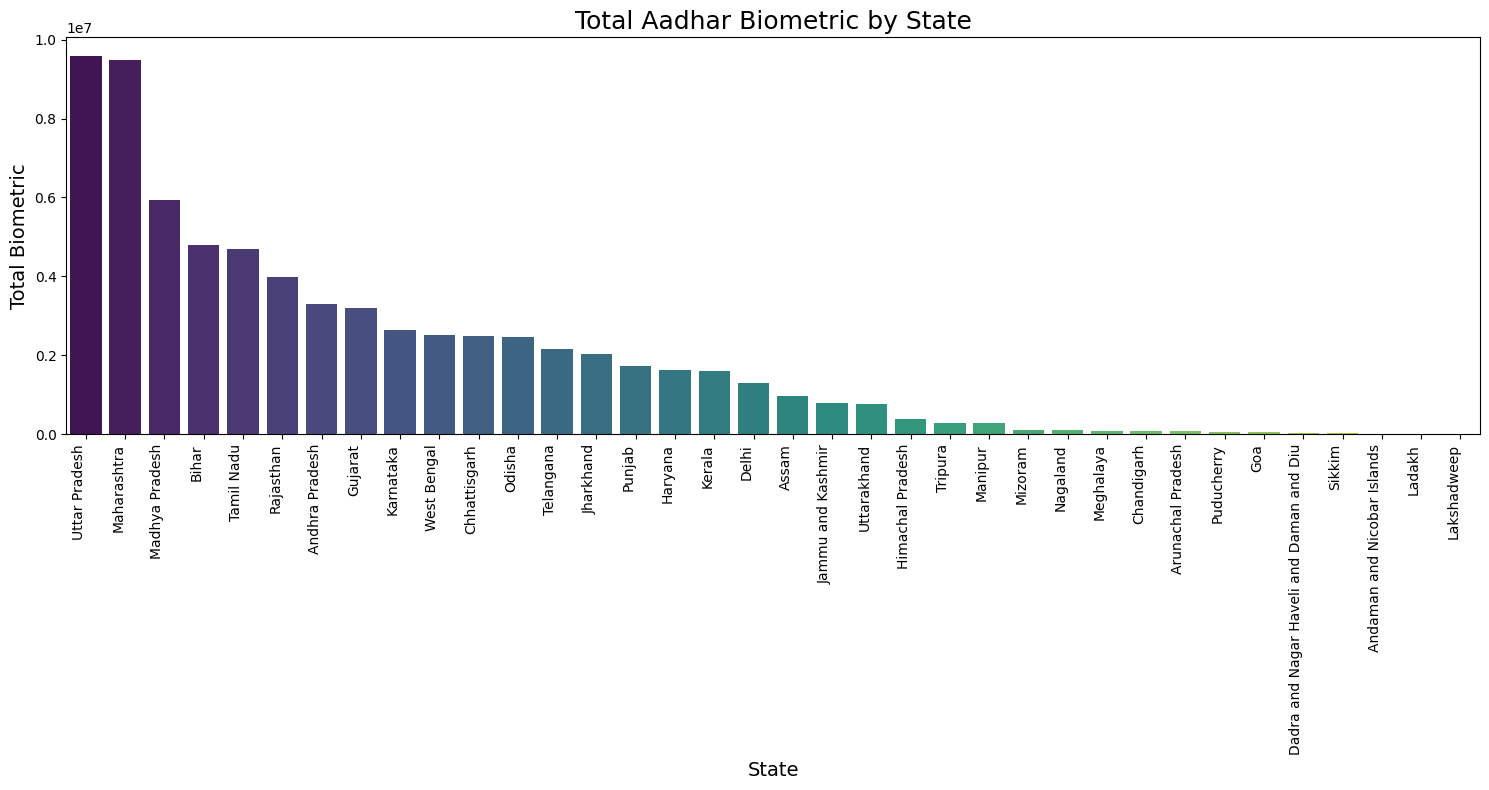

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(15, 8)) # Adjusted figure size for better readability of bar graph
sns.barplot(
    x='state',
    y='total_biometric',
    data=state_wise_total_biometric,
    palette='viridis' # Choose a color palette
)
plt.title('Total Aadhar Biometric by State', fontsize=18)
plt.xlabel('State', fontsize=14)
plt.ylabel('Total Biometric', fontsize=14)
plt.xticks(rotation=90, ha='right') # Rotate x-axis labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
selected_state = input("Enter the state name to generate a district-wise biometric bar graph: ")
districts_in_selected_state = state_district_wise_total_biometric[state_district_wise_total_biometric['state'] == selected_state]
if not districts_in_selected_state.empty:
    districts_in_selected_state = districts_in_selected_state.sort_values(by='total_biometric', ascending=False)
    plt.figure(figsize=(15, 8))
    sns.barplot(x='district', y='total_biometric',
                data=districts_in_selected_state,
                palette='viridis'
                )

    plt.title(f'District-wise Aadhar Biometric in {selected_state}', fontsize=18)
    plt.xlabel('District', fontsize=14)
    plt.ylabel('Total Biometric', fontsize=14)
    plt.xticks(rotation=90, ha='right') # Rotate x-axis labels for better readability
    plt.tight_layout() # Adjust layout to prevent labels from being cut off
    plt.show()
else:
    print(f"No data found for the state: {selected_state}. Please check the state name and try again.")

In [ ]:
total_peope_all_days = combined_df.groupby(['state'])['total_biometric'].sum()
count = combined_df.groupby(['state'])['total_biometric'].count()

In [ ]:
avg_people_each_state = total_peope_all_days/count
print(avg_people_each_state.sort_values(ascending=False))

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
import geopandas as gpd
from pyogrio import set_gdal_config_options
set_gdal_config_options({
    'SHAPE_RESTORE_SHX': 'YES',
})

In [ ]:
fp = r'india-polygon.shp'
map_df = gpd.read_file(fp)
map_df_copy = gpd.read_file(fp)
map_df.head()

In [ ]:
map_df['st_nm']

In [ ]:
df = pd.read_csv('downloaded_Biometric_Combined_data.csv')
total_peope_all_days = df.groupby(['state'])['total_biometric'].sum()
count = df.groupby(['state'])['total_biometric'].count()
avg_people_all_day = total_peope_all_days/count
merged = map_df.set_index('st_nm').join(avg_people_all_day)
merged

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
# fig, ax = plt.subplots(1, figsize=(10, 10))
# ax.axis('off')

# ax.set_title(
#     'Average Biometric Updates per State',
#     fontdict={'fontsize': '20', 'fontweight': '10'}
# )

# # Plot heatmap
# merged.plot(
#     column='total_biometric',
#     cmap='YlOrRd',
#     linewidth=0.8,
#     ax=ax,
#     edgecolor='0',
#     legend=True,
#     legend_kwds={'label': "Average biometric in a day"}
# )

# # Save as SVG
# fig.savefig("heatmap_biometric.svg", format="svg", bbox_inches="tight")

# plt.show()

fig, ax = plt.subplots(1, figsize=(10, 10))
ax.axis('off')
ax.set_title('Average Biometric Updates per State', fontdict={'fontsize': '20', 'fontweight' : '10'})
# Plot the figure
merged.plot(column='total_biometric', cmap='YlOrRd', linewidth=0.8, ax=ax, edgecolor='0', legend=True, legend_kwds={'label': "Average biometric in a day"})
plt.savefig("heatmap_biometric.svg")
plt.show()

In [ ]:
print(avg_people_each_state.sort_values(ascending=False))

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 8)) # Adjusted figure size for a bar graph
plt.title('Average Biometric per State', fontsize=18)
plt.xlabel('State', fontsize=14)
plt.ylabel('Average Biometric', fontsize=14)
avg_people_each_state_df = avg_people_each_state.reset_index()
avg_people_each_state_df.columns = ['state', 'average_biometric']
sns.barplot(x='state',y='average_biometric',
    data=avg_people_each_state_df.sort_values(by='average_biometric', ascending=False),
    palette='viridis'
)
plt.xticks(rotation=90, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
total_peope_of_age_5_17= combined_df.groupby(['state'])['bio_age_5_17'].sum()     #'bio_age_5_17'  'bio_age_17_'
count1= combined_df.groupby(['state'])['bio_age_5_17'].count()
avg_people_of_age_5_17= total_peope_of_age_5_17/count1
total_peope_of_age_17_= combined_df.groupby(['state'])['bio_age_17_'].sum()
count2= combined_df.groupby(['state'])['bio_age_17_'].count()
avg_people_of_age_17_ = total_peope_of_age_17_/count2

In [ ]:
import seaborn as sns, matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(20, 10)) # Adjusted figure size to be wider and shorter
fig.subplots_adjust(wspace=0.5) # Adjust space between subplots

# Plot for avg_people_of_age_5_17
sns.barplot(x=avg_people_of_age_5_17.index, y=avg_people_of_age_5_17.values, ax=ax[0], palette='viridis')
ax[0].set_title('Average Biometric for Age 5-17 by State')
ax[0].set_xlabel('State')
ax[0].set_ylabel('Average Biometric Count')
ax[0].tick_params(axis='x', rotation=90) # Rotate x-axis labels

# Plot for avg_people_of_age_17_
sns.barplot(x=avg_people_of_age_17_.index, y=avg_people_of_age_17_.values, ax=ax[1], palette='magma')
ax[1].set_title('Average Biometric for Age 17+ by State')
ax[1].set_xlabel('State')
ax[1].set_ylabel('Average Biometric Count')
ax[1].tick_params(axis='x', rotation=90) # Rotate x-axis labels

plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

In [ ]:
selected_state_for_district = input("Enter the state name to generate district-wise average biometric graphs: ")
df_filtered_state = combined_df[combined_df['state'] == selected_state_for_district]
if not df_filtered_state.empty:
    district_avg_5_17 = df_filtered_state.groupby('district')['bio_age_5_17'].sum() / df_filtered_state.groupby('district')['bio_age_5_17'].count()
    district_avg_17_ = df_filtered_state.groupby('district')['bio_age_17_'].sum() / df_filtered_state.groupby('district')['bio_age_17_'].count()
    fig, ax = plt.subplots(1, 2, figsize=(20, 10)) # Adjusted figure size
    fig.subplots_adjust(wspace=0.5)
    sns.barplot(x=district_avg_5_17.index, y=district_avg_5_17.values, ax=ax[0], palette='viridis')
    ax[0].set_title(f'Average Biometric for Age 5-17 in {selected_state_for_district} by District')
    ax[0].set_xlabel('District')
    ax[0].set_ylabel('Average Biometric Count')
    ax[0].tick_params(axis='x', rotation=90)
    sns.barplot(x=district_avg_17_.index, y=district_avg_17_.values, ax=ax[1], palette='magma')
    ax[1].set_title(f'Average Biometric for Age 17+ in {selected_state_for_district} by District')
    ax[1].set_xlabel('District')
    ax[1].set_ylabel('Average Biometric Count')
    ax[1].tick_params(axis='x', rotation=90)
    plt.tight_layout()
    plt.show()
else:
    print(f"No data found for the state: {selected_state_for_district}. Please check the state name and try again.")